In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PINN_3d import *
from FFEM_building_blocks import Mesh
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation

Mass matrix initialization completed
Stiffness matrix initialization completed


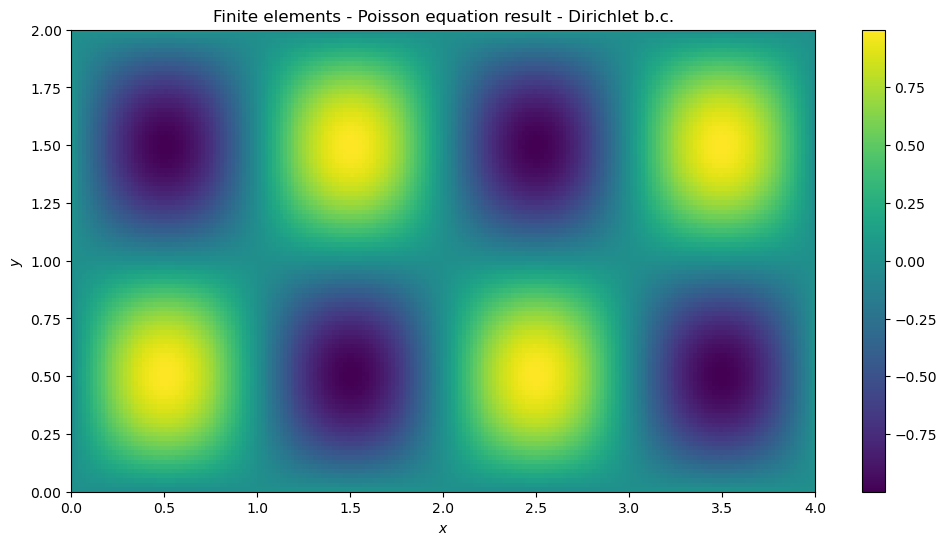

In [8]:
# As a reference solution, first compute the solution with the finite elements methods

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

mymesh = Mesh(x, y, verbose=True)
mymesh.build_mass_matrix()
mymesh.build_stiffness_matrix()

func = lambda x,y: 2.0 * np.pi**2 * np.sin(np.pi * x) * np.sin(np.pi * y)
diri = lambda x,y: 0
res_finite_elements = mymesh.run_simulation_poisson_dirichlet(func, diri)

plt.figure(figsize=(12, 6))
plt.imshow(res_finite_elements, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()]) # need origin "lower"
plt.colorbar()
plt.title('Finite elements - Poisson equation result - Dirichlet b.c.')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson.png')


In [3]:
# Example of a basic case for automatic differentiation with PyTorch

x = torch.tensor(3.0, requires_grad=True)
y = x**2
y.backward()
# y.backward() saves the gradient back on x. Note that backward destryos the graph, so if I want to apply the graph another time I have to add retain_graph = True
print(x.grad)

tensor(6.)


In [10]:
f_poisson_torch = lambda x: 2.0 * torch.pi**2 * torch.sin(torch.pi * x[:, 0:1]) * torch.sin(torch.pi * x[:, 1:2])

trial_PINN = PINN_Poisson_2d(32, f_poisson_torch, lambda x: 0)
# attention, the Dirichlet and Poisson functions take lists [x, y] as inputs
trial_PINN.set_collocation_points(400, (0,4), (0,2))
trial_PINN.compute_boundary_values(100, (0,4), (0,2))

trial_PINN.train(100000)

Epoch [1000/100000], Loss: 0.1970
Epoch [2000/100000], Loss: 0.0199
Epoch [3000/100000], Loss: 0.0284
Epoch [4000/100000], Loss: 0.0368
Epoch [5000/100000], Loss: 0.1203
Epoch [6000/100000], Loss: 0.0604
Epoch [7000/100000], Loss: 0.0444
Epoch [8000/100000], Loss: 0.0086
Epoch [9000/100000], Loss: 0.0403
Epoch [10000/100000], Loss: 0.0166
Epoch [11000/100000], Loss: 0.0168
Epoch [12000/100000], Loss: 0.0224
Epoch [13000/100000], Loss: 0.0103
Epoch [14000/100000], Loss: 0.0038
Epoch [15000/100000], Loss: 0.0201
Epoch [16000/100000], Loss: 0.0070
Epoch [17000/100000], Loss: 0.0071
Epoch [18000/100000], Loss: 0.0246
Epoch [19000/100000], Loss: 0.0151
Epoch [20000/100000], Loss: 0.0105
Epoch [21000/100000], Loss: 0.0144
Epoch [22000/100000], Loss: 0.0369
Epoch [23000/100000], Loss: 0.0037
Epoch [24000/100000], Loss: 0.0113
Epoch [25000/100000], Loss: 0.0025
Epoch [26000/100000], Loss: 0.0062
Epoch [27000/100000], Loss: 0.1460
Epoch [28000/100000], Loss: 0.0152
Epoch [29000/100000], Loss: 0

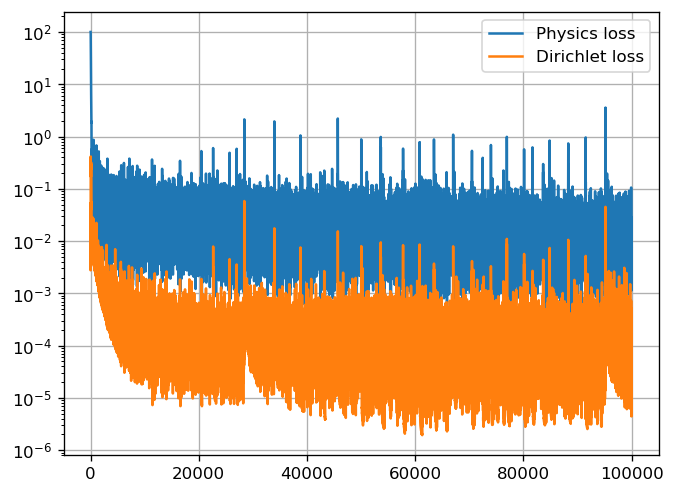

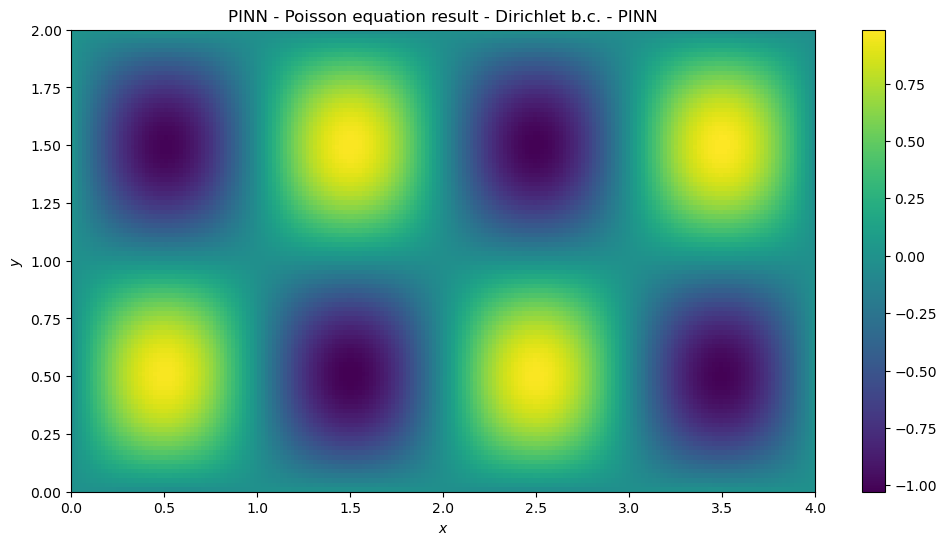

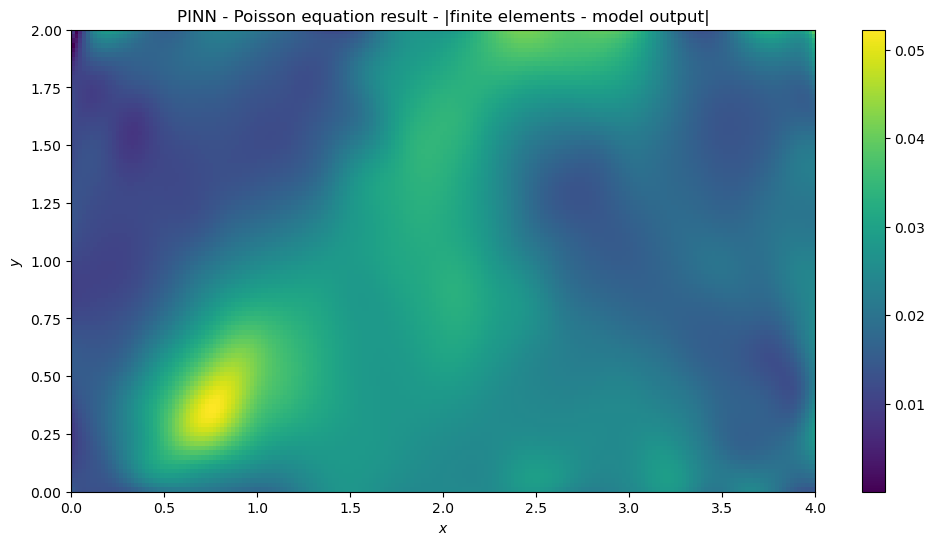

In [11]:

plt.figure(dpi= 120)
plt.semilogy(trial_PINN.epochs, trial_PINN.physics_losses, label = "Physics loss")
plt.semilogy(trial_PINN.epochs, trial_PINN.dirichlet_losses, label = "Dirichlet loss")
plt.grid(True)
plt.legend()
plt.show()

x = np.linspace(0, 4, 200)
y = np.linspace(0, 2, 100)

# build (N, 2) grid points in the same row-major order as imshow expects: shape (len(y), len(x))
X, Y = np.meshgrid(x, y)  # X, Y both shape (100, 200)
grid_points = np.stack([X.ravel(), Y.ravel()], axis=1)  # shape (20000, 2)
grid_points_torch = torch.tensor(grid_points, dtype=torch.float32)

with torch.no_grad():
    u_pred = trial_PINN.model(grid_points_torch)  # shape (20000, 1)

res = u_pred.numpy().reshape(len(y), len(x))  # back to (100, 200) to match X, Y grid

plt.figure(figsize=(12, 6))
plt.imshow(res, cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - Dirichlet b.c. - PINN')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/poisson_pinn.png')
plt.show()


plt.figure(figsize=(12, 6))
plt.imshow(np.abs(res - res_finite_elements), cmap='viridis', origin='lower', aspect='auto', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar()
plt.title('PINN - Poisson equation result - |finite elements - model output|')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.savefig('results/difference_FE_PINN_poisson.png')
plt.show()

pretty large values for both losses, especially the physics loss? 

**TO DO: tests varying dimensions and number of collocation and boundary points. When best convergence and overall results?**